# r5py vs Baseline Pipeline Comparison
## Jabodetabek Transit Equity Mapper — TAI Pipeline Validation

This notebook compares two pipeline runs:
- **Baseline (no r5py)**: L3 set to placeholder 0.5 for all kelurahan
- **With r5py**: L3 computed via r5py multimodal routing (gravity-weighted travel time to CBD zones)

L4 and L5 are still placeholder 0.5 in both runs. The only change is L3.

**TAI formula:** `TAI = 0.20·L1 + 0.15·L2 + 0.35·L3 + 0.15·L4 + 0.15·L5`

Because L3 carries 35% weight, routing-realistic values propagate strongly into TAI and all downstream equity metrics.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path

# paths — notebook lives in notebooks/, data at repo root
REPO = Path('..')
BASELINE_GEO = REPO / 'cache/baseline_no_r5py/kelurahan_scores.geojson'
BASELINE_EQ  = REPO / 'cache/baseline_no_r5py/equity_summary.json'
R5PY_GEO     = REPO / 'data/processed/scores/kelurahan_scores.geojson'
R5PY_EQ      = REPO / 'data/processed/analysis/equity_summary.json'

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

PALETTE = {'baseline': '#4878CF', 'r5py': '#E84545', 'delta': '#2CA02C'}
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Data — Overview

In [2]:
gdf_b = gpd.read_file(BASELINE_GEO)
gdf_r = gpd.read_file(R5PY_GEO)

with open(BASELINE_EQ) as f:
    eq_b = json.load(f)
with open(R5PY_EQ) as f:
    eq_r = json.load(f)

print('=== Dataset shape ===')
print(f'Baseline kelurahan:  {gdf_b.shape[0]} rows x {gdf_b.shape[1]} cols')
print(f'R5py kelurahan:      {gdf_r.shape[0]} rows x {gdf_r.shape[1]} cols')

LAYER_COLS = ['tai_l1_first_mile', 'tai_l2_service_quality',
              'tai_l3_cbd_journey', 'tai_l4_last_mile',
              'tai_l5_cost_competitiveness', 'tai_score']

print('\n=== TAI component summary (baseline vs r5py) ===')
summary = pd.DataFrame({
    'Baseline mean': gdf_b[LAYER_COLS].mean(),
    'Baseline std':  gdf_b[LAYER_COLS].std(),
    'R5py mean':     gdf_r[LAYER_COLS].mean(),
    'R5py std':      gdf_r[LAYER_COLS].std(),
})
summary['Delta mean'] = summary['R5py mean'] - summary['Baseline mean']
summary['Delta %'] = (summary['Delta mean'] / summary['Baseline mean'] * 100).round(1)
print(summary.round(4).to_string())

=== Dataset shape ===
Baseline kelurahan:  1502 rows x 47 cols
R5py kelurahan:      1502 rows x 47 cols

=== TAI component summary (baseline vs r5py) ===
                             Baseline mean  Baseline std  R5py mean  R5py std  Delta mean  Delta %
tai_l1_first_mile                   0.2133        0.1187     0.2133    0.1187      0.0000      0.0
tai_l2_service_quality              0.1968        0.3931     0.1968    0.3931      0.0000      0.0
tai_l3_cbd_journey                  0.5000        0.0000     0.0958    0.2221     -0.4042    -80.8
tai_l4_last_mile                    0.5000        0.0000     0.5000    0.0000      0.0000      0.0
tai_l5_cost_competitiveness         0.5000        0.0000     0.5000    0.0000      0.0000      0.0
tai_score                           0.3972        0.0774     0.2557    0.1395     -0.1415    -35.6


---
## 2. TAI Distribution Comparison

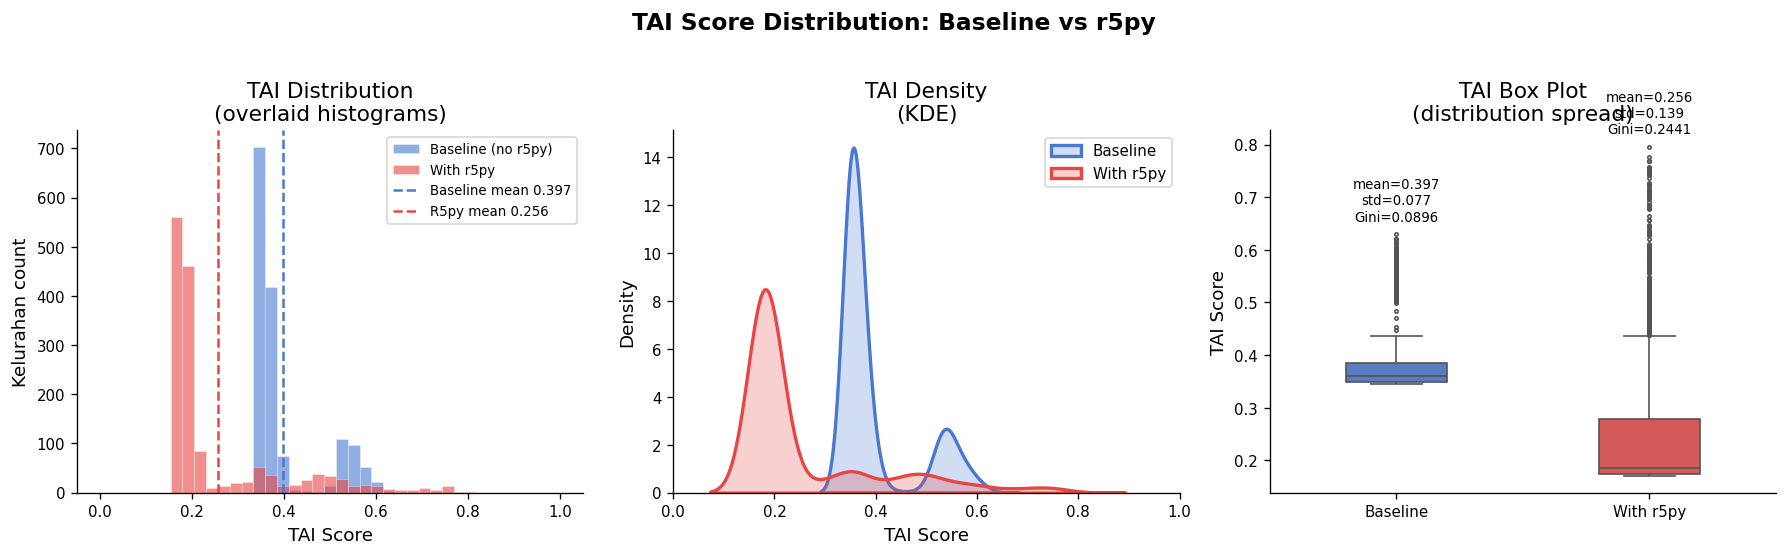


Key stats:
  Baseline  — mean: 0.3972, std: 0.0774, Gini: 0.0896
  With r5py — mean: 0.2557, std: 0.1395, Gini: 0.2441
  Delta mean: -0.1415  (-35.6%)
  Delta Gini: +0.1545


In [3]:
tai_b = gdf_b['tai_score']
tai_r = gdf_r['tai_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# subplot 1: overlaid histograms
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(tai_b, bins=bins, alpha=0.6, color=PALETTE['baseline'],
        label='Baseline (no r5py)', edgecolor='white', linewidth=0.3)
ax.hist(tai_r, bins=bins, alpha=0.6, color=PALETTE['r5py'],
        label='With r5py', edgecolor='white', linewidth=0.3)
ax.axvline(tai_b.mean(), color=PALETTE['baseline'], linestyle='--', linewidth=1.5,
           label=f'Baseline mean {tai_b.mean():.3f}')
ax.axvline(tai_r.mean(), color=PALETTE['r5py'], linestyle='--', linewidth=1.5,
           label=f'R5py mean {tai_r.mean():.3f}')
ax.set_xlabel('TAI Score')
ax.set_ylabel('Kelurahan count')
ax.set_title('TAI Distribution\n(overlaid histograms)')
ax.legend(fontsize=8)

# subplot 2: KDE
ax = axes[1]
kde_df = pd.DataFrame({
    'TAI': pd.concat([tai_b, tai_r], ignore_index=True),
    'Run': ['Baseline']*len(tai_b) + ['With r5py']*len(tai_r)
})
for run, col in [('Baseline', PALETTE['baseline']), ('With r5py', PALETTE['r5py'])]:
    subset = kde_df[kde_df['Run'] == run]['TAI']
    sns.kdeplot(subset, ax=ax, color=col, linewidth=2,
                fill=True, alpha=0.25, label=run)
ax.set_xlabel('TAI Score')
ax.set_ylabel('Density')
ax.set_title('TAI Density\n(KDE)')
ax.legend()
ax.set_xlim(0, 1)

# subplot 3: boxplot
ax = axes[2]
box_df = pd.DataFrame({
    'TAI': pd.concat([tai_b, tai_r], ignore_index=True),
    'Run': ['Baseline']*len(tai_b) + ['With r5py']*len(tai_r)
})
sns.boxplot(data=box_df, x='Run', y='TAI',
            palette=['#4878CF', '#E84545'], ax=ax,
            width=0.4, fliersize=2)
ax.set_xlabel('')
ax.set_ylabel('TAI Score')
ax.set_title('TAI Box Plot\n(distribution spread)')
gini_vals = [eq_b['kelurahan']['gini_tai'], eq_r['kelurahan']['gini_tai']]
for i, (run, vals, gini) in enumerate([
        ('Baseline', tai_b, gini_vals[0]),
        ('With r5py', tai_r, gini_vals[1])]):
    ax.text(i, vals.max() + 0.02,
            f'mean={vals.mean():.3f}\nstd={vals.std():.3f}\nGini={gini:.4f}',
            ha='center', va='bottom', fontsize=8)

plt.suptitle('TAI Score Distribution: Baseline vs r5py', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tai_distribution_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nKey stats:')
print(f'  Baseline  — mean: {tai_b.mean():.4f}, std: {tai_b.std():.4f}, Gini: {eq_b["kelurahan"]["gini_tai"]:.4f}')
print(f'  With r5py — mean: {tai_r.mean():.4f}, std: {tai_r.std():.4f}, Gini: {eq_r["kelurahan"]["gini_tai"]:.4f}')
print(f'  Delta mean: {tai_r.mean()-tai_b.mean():.4f}  ({(tai_r.mean()-tai_b.mean())/tai_b.mean()*100:+.1f}%)')
print(f'  Delta Gini: {eq_r["kelurahan"]["gini_tai"]-eq_b["kelurahan"]["gini_tai"]:+.4f}')

---
## 3. Layer-by-Layer Comparison (L1–L5)

L1 and L2 are identical in both runs — no routing involved.  
**L3 (CBD journey chain) is the only changed layer** — computed by r5py.  
L4 and L5 remain at placeholder 0.5 in both runs.

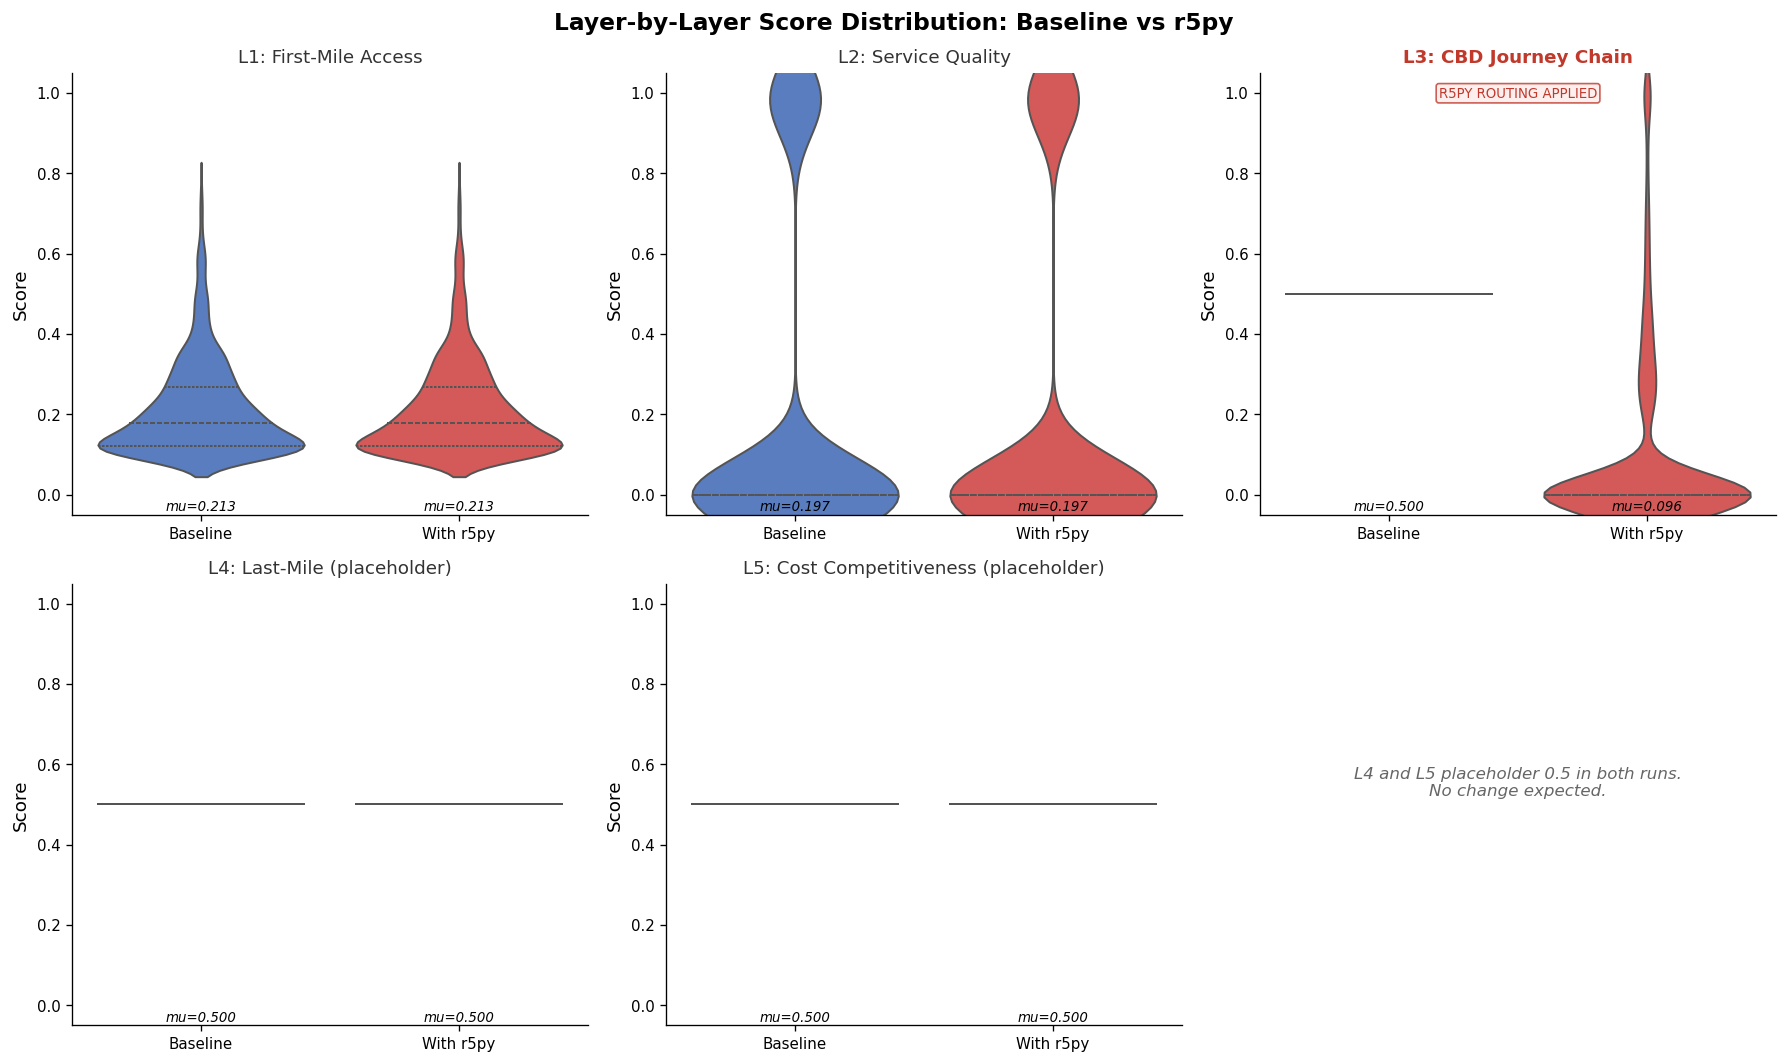


Layer delta summary (r5py mean - baseline mean):
  L1: First-Mile Access                         delta = +0.0000
  L2: Service Quality                           delta = +0.0000
  L3: CBD Journey Chain                         delta = -0.4042  <- CHANGED
  L4: Last-Mile (placeholder)                   delta = +0.0000
  L5: Cost Competitiveness (placeholder)        delta = +0.0000


In [4]:
LAYERS = [
    ('tai_l1_first_mile',          'L1: First-Mile Access',           False),
    ('tai_l2_service_quality',      'L2: Service Quality',             False),
    ('tai_l3_cbd_journey',          'L3: CBD Journey Chain',           True),
    ('tai_l4_last_mile',            'L4: Last-Mile (placeholder)',     False),
    ('tai_l5_cost_competitiveness', 'L5: Cost Competitiveness (placeholder)', False),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (col, label, changed) in enumerate(LAYERS):
    ax = axes[i]
    v_b = gdf_b[col]
    v_r = gdf_r[col]

    viol_df = pd.DataFrame({
        'Score': pd.concat([v_b, v_r], ignore_index=True),
        'Run':   ['Baseline']*len(v_b) + ['With r5py']*len(v_r)
    })
    palette = {'Baseline': PALETTE['baseline'], 'With r5py': PALETTE['r5py']}
    sns.violinplot(data=viol_df, x='Run', y='Score', palette=palette,
                   ax=ax, inner='quartile', linewidth=1.2)

    title_color = '#C0392B' if changed else '#333'
    ax.set_title(label, fontsize=11, color=title_color,
                 fontweight='bold' if changed else 'normal')
    ax.set_xlabel('')
    ax.set_ylabel('Score')
    ax.set_ylim(-0.05, 1.05)

    if changed:
        ax.text(0.5, 0.97, 'R5PY ROUTING APPLIED',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=8, color='#C0392B',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#FDECEA',
                          edgecolor='#C0392B', alpha=0.8))

    for j, vals in enumerate([v_b, v_r]):
        ax.text(j, -0.04, f'mu={vals.mean():.3f}', ha='center', fontsize=8, style='italic')

# turn off unused subplot
axes[5].axis('off')
axes[5].text(0.5, 0.55,
             'L4 and L5 placeholder 0.5 in both runs.\nNo change expected.',
             ha='center', va='center', fontsize=10, style='italic',
             color='#666', transform=axes[5].transAxes)

plt.suptitle('Layer-by-Layer Score Distribution: Baseline vs r5py', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('layer_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nLayer delta summary (r5py mean - baseline mean):')
for col, label, changed in LAYERS:
    delta = gdf_r[col].mean() - gdf_b[col].mean()
    flag = '  <- CHANGED' if changed else ''
    print(f'  {label:<45} delta = {delta:+.4f}{flag}')

---
## 4. Spatial Comparison — Choropleth Maps

Three maps: Baseline TAI | r5py TAI | Delta (r5py − baseline)

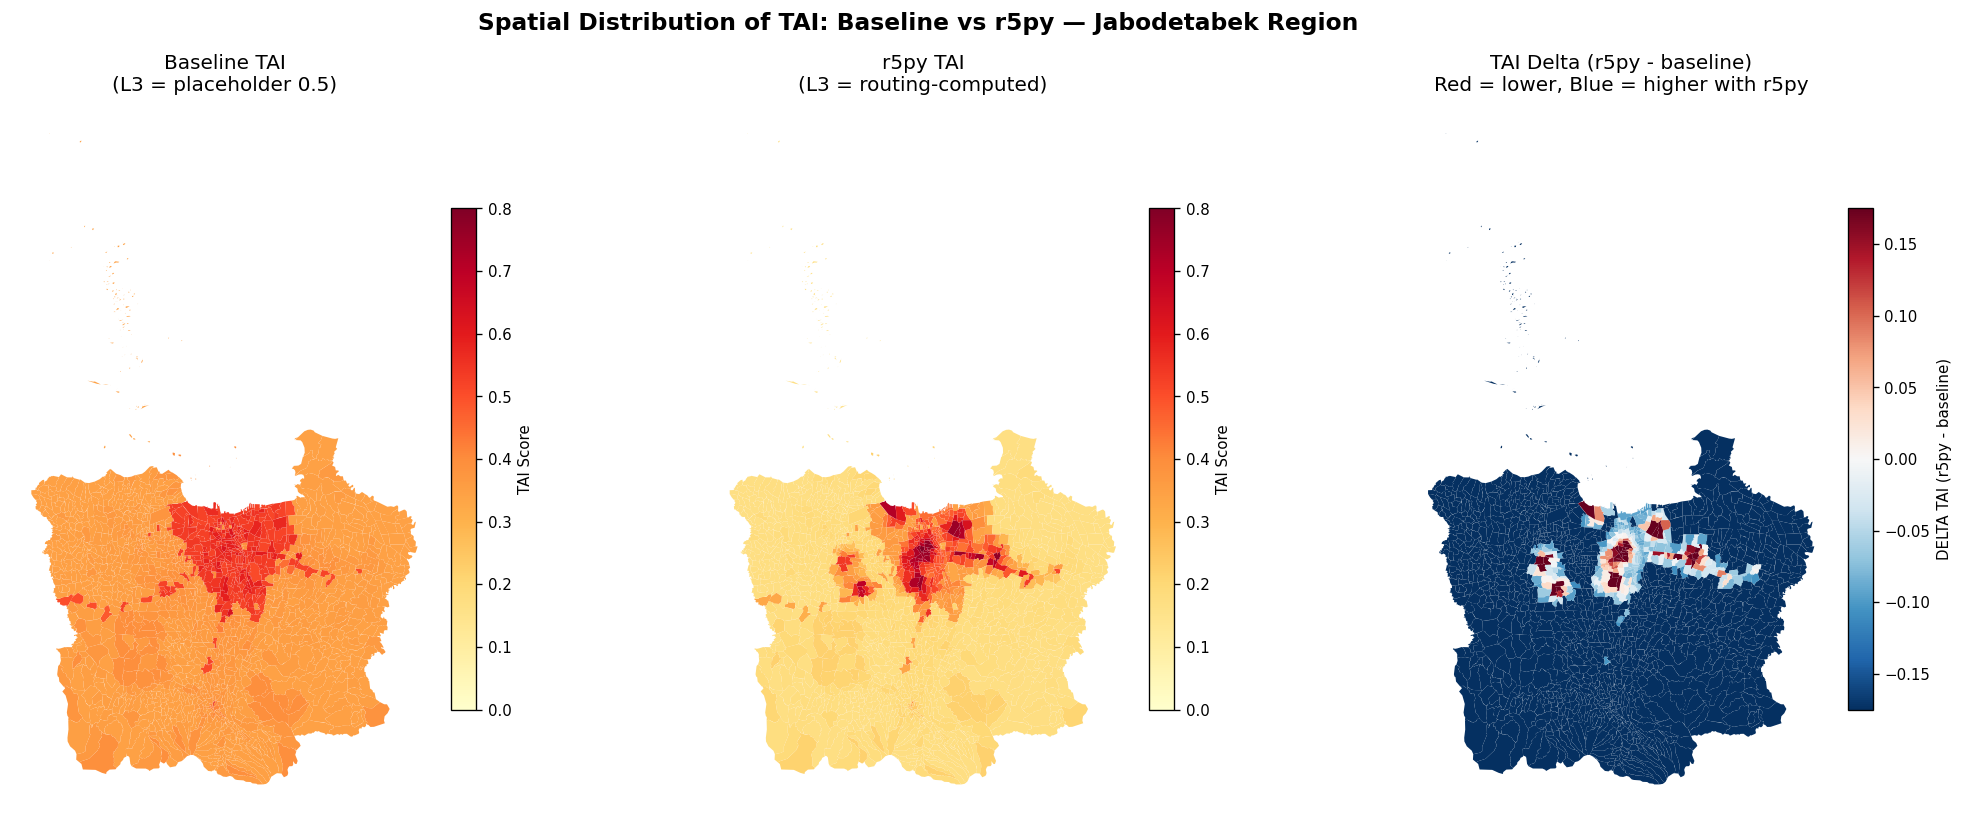

Delta stats:
  mean: -0.1415
  std:  0.0778
  min:  -0.1750
  max:  +0.1750
  kelurahan lower with r5py:  1399 (93.1%)
  kelurahan higher with r5py: 103 (6.9%)


In [5]:
# compute delta
gdf_delta = gdf_r[['kelurahan_id', 'geometry']].copy()
gdf_delta['tai_delta'] = gdf_r['tai_score'].values - gdf_b['tai_score'].values

TAI_CMAP = 'YlOrRd'
TAI_VMIN, TAI_VMAX = 0.0, 0.8
delta_max = float(gdf_delta['tai_delta'].abs().quantile(0.98))
DELTA_NORM = TwoSlopeNorm(vmin=-delta_max, vcenter=0, vmax=delta_max)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# map 1: baseline TAI
ax = axes[0]
gdf_b.plot(column='tai_score', ax=ax, cmap=TAI_CMAP,
           vmin=TAI_VMIN, vmax=TAI_VMAX, linewidth=0, legend=False)
sm1 = plt.cm.ScalarMappable(cmap=TAI_CMAP,
          norm=plt.Normalize(vmin=TAI_VMIN, vmax=TAI_VMAX))
sm1.set_array([])
cbar1 = fig.colorbar(sm1, ax=ax, shrink=0.7, pad=0.02)
cbar1.set_label('TAI Score', fontsize=9)
ax.set_title('Baseline TAI\n(L3 = placeholder 0.5)', fontsize=12)
ax.axis('off')

# map 2: r5py TAI
ax = axes[1]
gdf_r.plot(column='tai_score', ax=ax, cmap=TAI_CMAP,
           vmin=TAI_VMIN, vmax=TAI_VMAX, linewidth=0, legend=False)
sm2 = plt.cm.ScalarMappable(cmap=TAI_CMAP,
          norm=plt.Normalize(vmin=TAI_VMIN, vmax=TAI_VMAX))
sm2.set_array([])
cbar2 = fig.colorbar(sm2, ax=ax, shrink=0.7, pad=0.02)
cbar2.set_label('TAI Score', fontsize=9)
ax.set_title('r5py TAI\n(L3 = routing-computed)', fontsize=12)
ax.axis('off')

# map 3: delta
ax = axes[2]
gdf_delta.plot(column='tai_delta', ax=ax, cmap='RdBu_r',
               norm=DELTA_NORM, linewidth=0, legend=False)
sm3 = plt.cm.ScalarMappable(cmap='RdBu_r', norm=DELTA_NORM)
sm3.set_array([])
cbar3 = fig.colorbar(sm3, ax=ax, shrink=0.7, pad=0.02)
cbar3.set_label('DELTA TAI (r5py - baseline)', fontsize=9)
ax.set_title('TAI Delta (r5py - baseline)\nRed = lower, Blue = higher with r5py', fontsize=12)
ax.axis('off')

plt.suptitle('Spatial Distribution of TAI: Baseline vs r5py — Jabodetabek Region',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('spatial_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

print('Delta stats:')
print(f'  mean: {gdf_delta["tai_delta"].mean():+.4f}')
print(f'  std:  {gdf_delta["tai_delta"].std():.4f}')
print(f'  min:  {gdf_delta["tai_delta"].min():+.4f}')
print(f'  max:  {gdf_delta["tai_delta"].max():+.4f}')
n_lower = int((gdf_delta['tai_delta'] < 0).sum())
n_higher = int((gdf_delta['tai_delta'] > 0).sum())
print(f'  kelurahan lower with r5py:  {n_lower} ({n_lower/len(gdf_delta)*100:.1f}%)')
print(f'  kelurahan higher with r5py: {n_higher} ({n_higher/len(gdf_delta)*100:.1f}%)')

---
## 5. Quadrant Shift Analysis

Each kelurahan is assigned to a quadrant based on TAI vs TNI scores:
- **Q1**: High TAI, High TNI — transit-served, high-need (equity win)
- **Q2**: Low TAI, High TNI — transit deserts (equity crisis)
- **Q3**: High TAI, Low TNI — low-need served areas
- **Q4**: Low TAI, Low TNI — low-need, low service

How many kelurahan shifted quadrant when L3 was replaced by real routing data?

=== Quadrant transition matrix (Baseline -> r5py) ===
r5py       Q1   Q2   Q3   Q4
Baseline                    
Q1        331    0    0    7
Q2          0  406    7    0
Q3          0   11  327    0
Q4          5    0    0  408

Kelurahan unchanged: 1472 (98.0%)
Kelurahan shifted:   30 (2.0%)


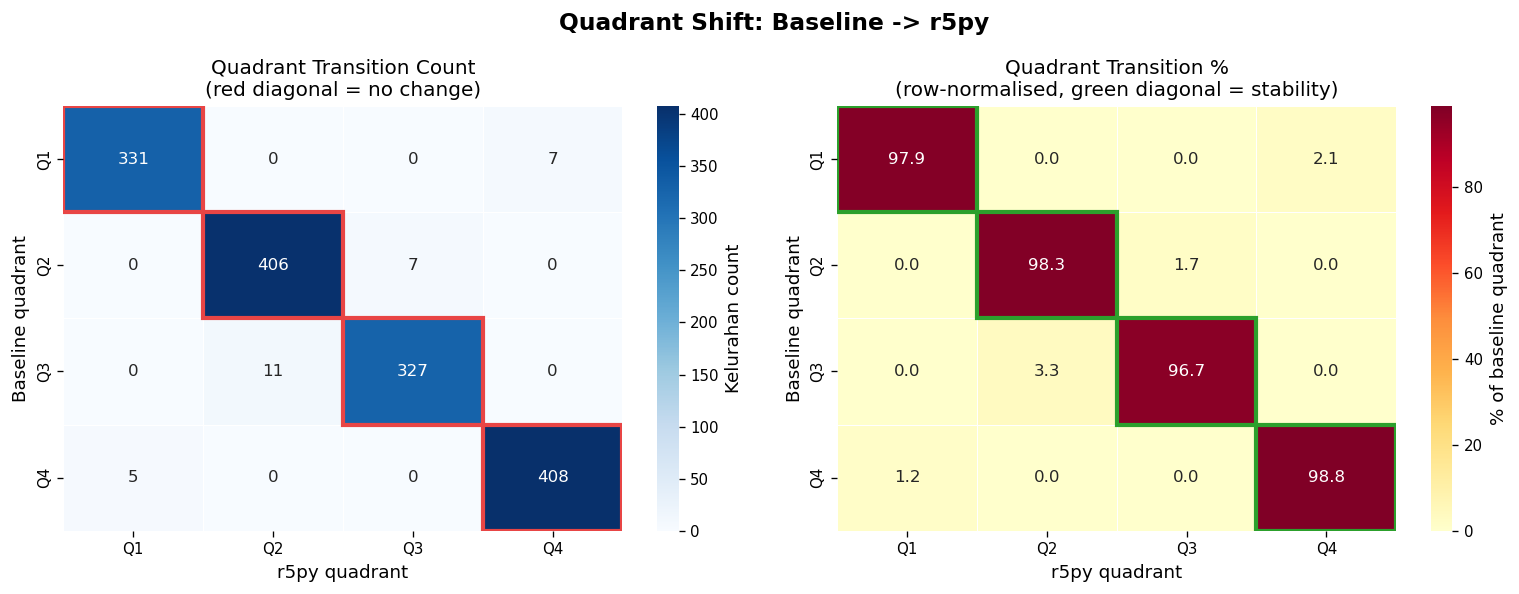

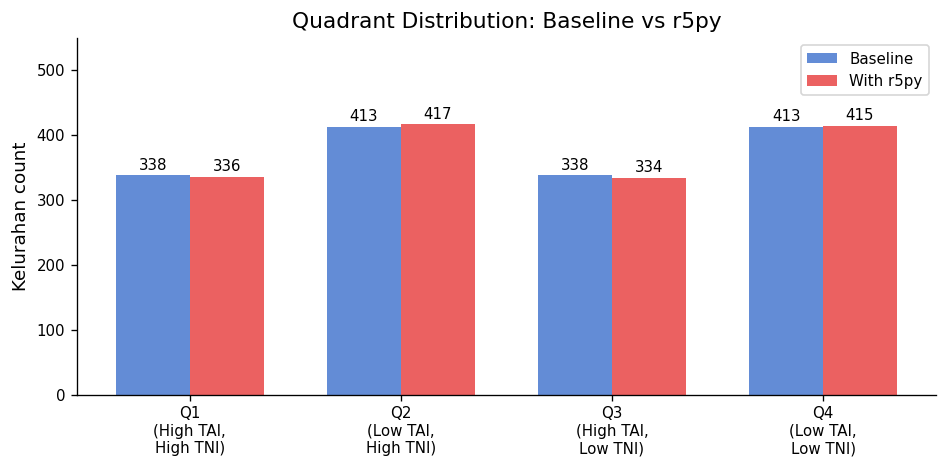

In [6]:
quad_df = pd.DataFrame({
    'kelurahan_id': gdf_b['kelurahan_id'],
    'Q_baseline':   gdf_b['quadrant'],
    'Q_r5py':       gdf_r['quadrant'],
})

transition = pd.crosstab(
    quad_df['Q_baseline'], quad_df['Q_r5py'],
    rownames=['Baseline'], colnames=['r5py']
)

print('=== Quadrant transition matrix (Baseline -> r5py) ===')
print(transition)

total = len(quad_df)
unchanged = (quad_df['Q_baseline'] == quad_df['Q_r5py']).sum()
shifted = total - unchanged
print(f'\nKelurahan unchanged: {unchanged} ({unchanged/total*100:.1f}%)')
print(f'Kelurahan shifted:   {shifted} ({shifted/total*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# counts heatmap
ax = axes[0]
sns.heatmap(transition, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Kelurahan count'})
for i in range(len(transition)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor='#E84545', lw=2.5))
ax.set_title('Quadrant Transition Count\n(red diagonal = no change)', fontsize=12)
ax.set_xlabel('r5py quadrant')
ax.set_ylabel('Baseline quadrant')

# row-normalised percentage heatmap
ax = axes[1]
transition_pct = transition.div(transition.sum(axis=1), axis=0) * 100
sns.heatmap(transition_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '% of baseline quadrant'})
for i in range(len(transition_pct)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                edgecolor='#2CA02C', lw=2.5))
ax.set_title('Quadrant Transition %\n(row-normalised, green diagonal = stability)', fontsize=12)
ax.set_xlabel('r5py quadrant')
ax.set_ylabel('Baseline quadrant')

plt.suptitle('Quadrant Shift: Baseline -> r5py', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('quadrant_shift.png', bbox_inches='tight', dpi=150)
plt.show()

# bar chart: quadrant counts
fig, ax = plt.subplots(figsize=(8, 4))
q_labels = ['Q1', 'Q2', 'Q3', 'Q4']
q_b_vals = [eq_b['kelurahan']['quadrant_counts'][q] for q in q_labels]
q_r_vals = [eq_r['kelurahan']['quadrant_counts'][q] for q in q_labels]
x = np.arange(4)
w = 0.35
bars_b = ax.bar(x - w/2, q_b_vals, width=w, color=PALETTE['baseline'],
                label='Baseline', alpha=0.85)
bars_r = ax.bar(x + w/2, q_r_vals, width=w, color=PALETTE['r5py'],
                label='With r5py', alpha=0.85)
for bars in [bars_b, bars_r]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['Q1\n(High TAI,\nHigh TNI)', 'Q2\n(Low TAI,\nHigh TNI)',
                     'Q3\n(High TAI,\nLow TNI)', 'Q4\n(Low TAI,\nLow TNI)'])
ax.set_ylabel('Kelurahan count')
ax.set_title('Quadrant Distribution: Baseline vs r5py')
ax.legend()
ax.set_ylim(0, 550)
plt.tight_layout()
plt.savefig('quadrant_counts.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Equity Metrics Comparison

Gini coefficients, Moran's I spatial autocorrelation, LISA cluster counts, and the H2 cross-resolution hypothesis.

In [7]:
rows = [
    ('TAI Gini (kelurahan)',
     eq_b['kelurahan']['gini_tai'],
     eq_r['kelurahan']['gini_tai']),
    ('Equity Gap Gini (kelurahan)',
     eq_b['kelurahan']['gini_equity_gap'],
     eq_r['kelurahan']['gini_equity_gap']),
    ('TNI Gini (kelurahan)',
     eq_b['kelurahan']['gini_tni'],
     eq_r['kelurahan']['gini_tni']),
    ("Moran's I TAI (kelurahan)",
     eq_b['kelurahan']['global_morans_i_tai']['moran_i'],
     eq_r['kelurahan']['global_morans_i_tai']['moran_i']),
    ("Moran's I Equity Gap (kelurahan)",
     eq_b['kelurahan']['global_morans_i_equity_gap']['moran_i'],
     eq_r['kelurahan']['global_morans_i_equity_gap']['moran_i']),
    ('LISA HH clusters',
     eq_b['kelurahan']['lisa_cluster_counts']['HH'],
     eq_r['kelurahan']['lisa_cluster_counts']['HH']),
    ('LISA LL clusters',
     eq_b['kelurahan']['lisa_cluster_counts']['LL'],
     eq_r['kelurahan']['lisa_cluster_counts']['LL']),
    ('LISA NS (not significant)',
     eq_b['kelurahan']['lisa_cluster_counts']['NS'],
     eq_r['kelurahan']['lisa_cluster_counts']['NS']),
    ('Q4 transit deserts (count)',
     eq_b['kelurahan']['quadrant_counts']['Q4'],
     eq_r['kelurahan']['quadrant_counts']['Q4']),
    ('Q4 transit deserts (%)',
     eq_b['kelurahan']['q4_pct'],
     eq_r['kelurahan']['q4_pct']),
    ('TAI Gini H3 (not rerun)',
     eq_b['h3']['gini_tai'],
     eq_r['h3']['gini_tai']),
    ('H2: Gini_H3 > Gini_kelurahan',
     eq_b['h2_hypothesis_signal']['gini_h3_gt_kelurahan'],
     eq_r['h2_hypothesis_signal']['gini_h3_gt_kelurahan']),
    ('H2 Gini delta (H3 - kelurahan)',
     eq_b['h2_hypothesis_signal']['gini_delta'],
     eq_r['h2_hypothesis_signal']['gini_delta']),
    ("Cohen's kappa (H3 vs kelurahan)",
     eq_b['resolution_comparison']['cohen_kappa'],
     eq_r['resolution_comparison']['cohen_kappa']),
    ('Kelurahan reclassified (%)',
     eq_b['resolution_comparison']['pct_reclassified'],
     eq_r['resolution_comparison']['pct_reclassified']),
]

df_m = pd.DataFrame(rows, columns=['Metric', 'Baseline', 'With r5py'])

def fmt_delta(b, r):
    try:
        d = float(r) - float(b)
        pct = d / float(b) * 100 if float(b) != 0 else float('nan')
        return f'{d:+.4f} ({pct:+.1f}%)'
    except (TypeError, ValueError):
        return str(r) + ' (was ' + str(b) + ')'

df_m['Delta'] = df_m.apply(lambda row: fmt_delta(row['Baseline'], row['With r5py']), axis=1)
print(df_m.to_string(index=False))

                          Metric Baseline With r5py             Delta
            TAI Gini (kelurahan)   0.0896    0.2441 +0.1545 (+172.4%)
     Equity Gap Gini (kelurahan)   0.3471    0.2608  -0.0863 (-24.9%)
            TNI Gini (kelurahan)   0.1091    0.1091   +0.0000 (+0.0%)
       Moran's I TAI (kelurahan)   0.8418    0.8876   +0.0458 (+5.4%)
Moran's I Equity Gap (kelurahan)   0.4934    0.6945  +0.2011 (+40.8%)
                LISA HH clusters      177       225 +48.0000 (+27.1%)
                LISA LL clusters      242       259  +17.0000 (+7.0%)
       LISA NS (not significant)     1022       985  -37.0000 (-3.6%)
      Q4 transit deserts (count)      413       415   +2.0000 (+0.5%)
          Q4 transit deserts (%)     27.5     27.63   +0.1300 (+0.5%)
         TAI Gini H3 (not rerun)   0.1228    0.1228   +0.0000 (+0.0%)
    H2: Gini_H3 > Gini_kelurahan     True     False -1.0000 (-100.0%)
  H2 Gini delta (H3 - kelurahan)   0.0332   -0.1212 -0.1544 (-465.1%)
 Cohen's kappa (H3 v

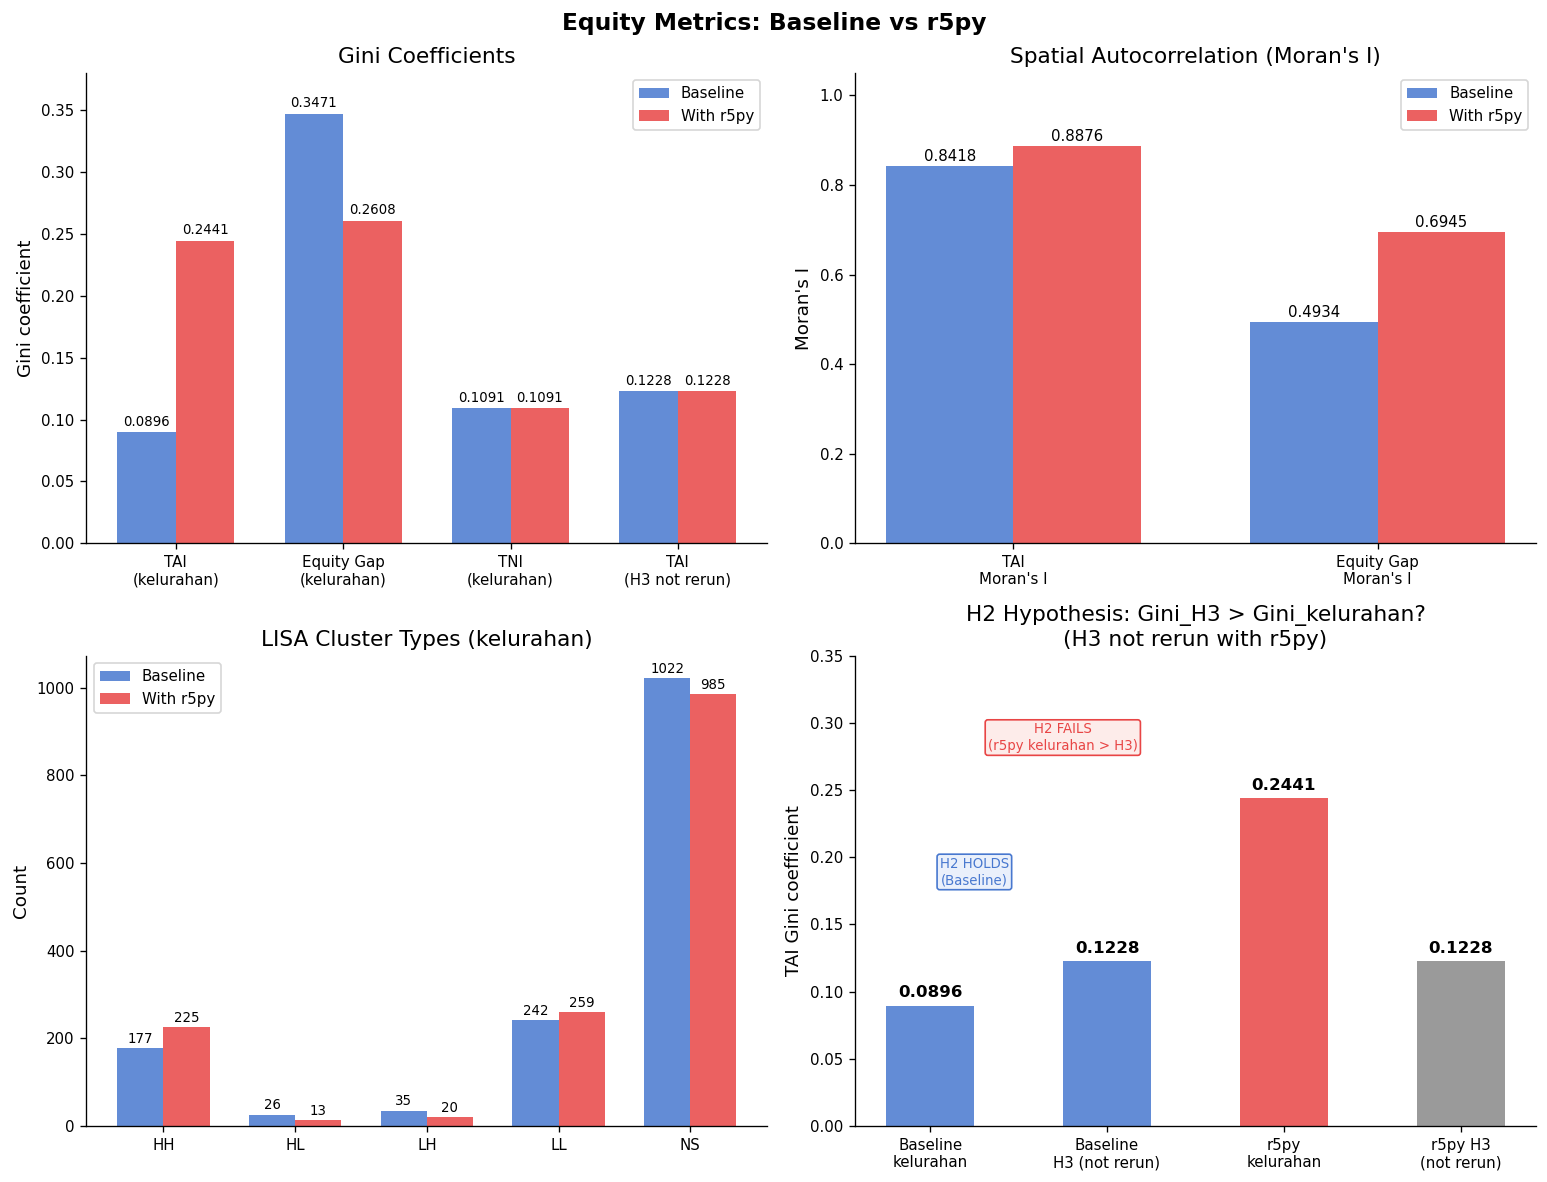

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# plot 1: Gini comparison
ax = axes[0, 0]
gini_labels = ['TAI\n(kelurahan)', 'Equity Gap\n(kelurahan)',
                'TNI\n(kelurahan)', 'TAI\n(H3 not rerun)']
gini_b = [eq_b['kelurahan']['gini_tai'], eq_b['kelurahan']['gini_equity_gap'],
           eq_b['kelurahan']['gini_tni'],  eq_b['h3']['gini_tai']]
gini_r = [eq_r['kelurahan']['gini_tai'], eq_r['kelurahan']['gini_equity_gap'],
           eq_r['kelurahan']['gini_tni'],  eq_r['h3']['gini_tai']]
x = np.arange(len(gini_labels))
w = 0.35
bars_b = ax.bar(x - w/2, gini_b, width=w, color=PALETTE['baseline'],
                label='Baseline', alpha=0.85)
bars_r = ax.bar(x + w/2, gini_r, width=w, color=PALETTE['r5py'],
                label='With r5py', alpha=0.85)
for bars in [bars_b, bars_r]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(gini_labels)
ax.set_ylabel('Gini coefficient')
ax.set_title('Gini Coefficients')
ax.legend()
ax.set_ylim(0, 0.38)

# plot 2: Moran's I
ax = axes[0, 1]
mi_labels = ["TAI\nMoran's I", "Equity Gap\nMoran's I"]
mi_b = [eq_b['kelurahan']['global_morans_i_tai']['moran_i'],
         eq_b['kelurahan']['global_morans_i_equity_gap']['moran_i']]
mi_r = [eq_r['kelurahan']['global_morans_i_tai']['moran_i'],
         eq_r['kelurahan']['global_morans_i_equity_gap']['moran_i']]
x2 = np.arange(2)
bars_b2 = ax.bar(x2 - w/2, mi_b, width=w, color=PALETTE['baseline'],
                 label='Baseline', alpha=0.85)
bars_r2 = ax.bar(x2 + w/2, mi_r, width=w, color=PALETTE['r5py'],
                 label='With r5py', alpha=0.85)
for bars in [bars_b2, bars_r2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x2)
ax.set_xticklabels(mi_labels)
ax.set_ylabel("Moran's I")
ax.set_title("Spatial Autocorrelation (Moran's I)")
ax.legend()
ax.set_ylim(0, 1.05)

# plot 3: LISA clusters
ax = axes[1, 0]
lisa_types = ['HH', 'HL', 'LH', 'LL', 'NS']
lisa_b_vals = [eq_b['kelurahan']['lisa_cluster_counts'][k] for k in lisa_types]
lisa_r_vals = [eq_r['kelurahan']['lisa_cluster_counts'][k] for k in lisa_types]
x3 = np.arange(5)
bars_b3 = ax.bar(x3 - w/2, lisa_b_vals, width=w, color=PALETTE['baseline'],
                 label='Baseline', alpha=0.85)
bars_r3 = ax.bar(x3 + w/2, lisa_r_vals, width=w, color=PALETTE['r5py'],
                 label='With r5py', alpha=0.85)
for bars in [bars_b3, bars_r3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x3)
ax.set_xticklabels(lisa_types)
ax.set_ylabel('Count')
ax.set_title('LISA Cluster Types (kelurahan)')
ax.legend()

# plot 4: H2 hypothesis visual
ax = axes[1, 1]
h2_labels = ['Baseline\nkelurahan', 'Baseline\nH3 (not rerun)',
             'r5py\nkelurahan', 'r5py H3\n(not rerun)']
h2_vals = [eq_b['kelurahan']['gini_tai'], eq_b['h3']['gini_tai'],
            eq_r['kelurahan']['gini_tai'], eq_r['h3']['gini_tai']]
h2_colors = [PALETTE['baseline'], PALETTE['baseline'],
              PALETTE['r5py'], '#888888']
bars_h2 = ax.bar(h2_labels, h2_vals, color=h2_colors, alpha=0.85, width=0.5)
for bar in bars_h2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.4f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold')
ax.set_ylabel('TAI Gini coefficient')
ax.set_title("H2 Hypothesis: Gini_H3 > Gini_kelurahan?\n(H3 not rerun with r5py)")
ax.set_ylim(0, 0.35)
# status annotations
ax.text(0.25, 0.18, 'H2 HOLDS\n(Baseline)', ha='center', fontsize=8,
        color=PALETTE['baseline'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#EAF0FB', edgecolor=PALETTE['baseline']))
ax.text(0.75, 0.28, 'H2 FAILS\n(r5py kelurahan > H3)', ha='center', fontsize=8,
        color=PALETTE['r5py'],
        bbox=dict(boxstyle='round,pad=0.2', facecolor='#FDECEA', edgecolor=PALETTE['r5py']))

plt.suptitle('Equity Metrics: Baseline vs r5py', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('equity_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Key Findings Summary

What changed when L3 was replaced by real r5py multimodal routing?

In [9]:
SEP = '=' * 72
print(SEP)
print('KEY FINDINGS: r5py vs Baseline Pipeline Comparison')
print(SEP)

print()
print('1. TAI MEAN DROPPED SIGNIFICANTLY')
print(f'   Baseline mean TAI : {gdf_b["tai_score"].mean():.4f}')
print(f'   r5py mean TAI     : {gdf_r["tai_score"].mean():.4f}')
delta_mean = gdf_r['tai_score'].mean() - gdf_b['tai_score'].mean()
print(f'   Delta             : {delta_mean:+.4f} ({delta_mean/gdf_b["tai_score"].mean()*100:+.1f}%)')
print('   -> Real routing shows lower average accessibility than placeholder assumed.')

print()
print('2. INEQUALITY REVEALED: GINI TRIPLED')
print(f'   Baseline Gini (TAI) : {eq_b["kelurahan"]["gini_tai"]:.4f}')
print(f'   r5py Gini (TAI)     : {eq_r["kelurahan"]["gini_tai"]:.4f}')
delta_gini = eq_r['kelurahan']['gini_tai'] - eq_b['kelurahan']['gini_tai']
print(f'   Delta Gini          : {delta_gini:+.4f} ({delta_gini/eq_b["kelurahan"]["gini_tai"]*100:+.1f}%)')
print('   -> Placeholder L3 masked substantial spatial inequality in CBD access.')

print()
print('3. SPATIAL CLUSTERING INTENSIFIED')
print(f'   Baseline Moran\'s I (TAI) : {eq_b["kelurahan"]["global_morans_i_tai"]["moran_i"]:.4f}')
print(f'   r5py Moran\'s I (TAI)     : {eq_r["kelurahan"]["global_morans_i_tai"]["moran_i"]:.4f}')
print('   -> Routing reveals high/low accessibility zones cluster more tightly.')

print()
print('4. LISA CLUSTERS SHARPENED')
hh_delta = eq_r['kelurahan']['lisa_cluster_counts']['HH'] - eq_b['kelurahan']['lisa_cluster_counts']['HH']
ll_delta = eq_r['kelurahan']['lisa_cluster_counts']['LL'] - eq_b['kelurahan']['lisa_cluster_counts']['LL']
ns_delta = eq_r['kelurahan']['lisa_cluster_counts']['NS'] - eq_b['kelurahan']['lisa_cluster_counts']['NS']
print(f'   HH : {eq_b["kelurahan"]["lisa_cluster_counts"]["HH"]} -> {eq_r["kelurahan"]["lisa_cluster_counts"]["HH"]} ({hh_delta:+d})')
print(f'   LL : {eq_b["kelurahan"]["lisa_cluster_counts"]["LL"]} -> {eq_r["kelurahan"]["lisa_cluster_counts"]["LL"]} ({ll_delta:+d})')
print(f'   NS : {eq_b["kelurahan"]["lisa_cluster_counts"]["NS"]} -> {eq_r["kelurahan"]["lisa_cluster_counts"]["NS"]} ({ns_delta:+d})')
print('   -> More kelurahan reclassified from NS to significant clusters.')

print()
print('5. H2 HYPOTHESIS FLIPPED')
print(f'   Baseline : Gini_H3 ({eq_b["h3"]["gini_tai"]:.4f}) > Gini_kel ({eq_b["kelurahan"]["gini_tai"]:.4f}) -> H2 HOLDS')
print(f'   r5py     : Gini_H3 ({eq_r["h3"]["gini_tai"]:.4f}) < Gini_kel ({eq_r["kelurahan"]["gini_tai"]:.4f}) -> H2 FAILS')
print('   -> H3 was NOT rerun with r5py. Kelurahan Gini is now higher.')
print('   -> H3 must be rerun with r5py routing before H2 can be properly tested.')

print()
print('6. QUADRANT DISTRIBUTION STABLE')
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    delta_q = eq_r['kelurahan']['quadrant_counts'][q] - eq_b['kelurahan']['quadrant_counts'][q]
    print(f'   {q}: {eq_b["kelurahan"]["quadrant_counts"][q]} -> {eq_r["kelurahan"]["quadrant_counts"][q]} ({delta_q:+d})')
print('   -> Overall quadrant distribution barely changed despite large Gini shift.')
print('   -> Relative ranking changed; absolute cutoff thresholds held.')

print()
print('7. CONCLUSION')
print('   r5py routing exposes real transit accessibility structure hidden by placeholder L3.')
print('   The Gini jump from 0.09 to 0.24 validates that L3 is the most important layer')
print('   and cannot be approximated with a flat placeholder.')
print('   Next step: rerun H3 hexagons with r5py L3 to re-test H2.')
print(SEP)

KEY FINDINGS: r5py vs Baseline Pipeline Comparison

1. TAI MEAN DROPPED SIGNIFICANTLY
   Baseline mean TAI : 0.3972
   r5py mean TAI     : 0.2557
   Delta             : -0.1415 (-35.6%)
   -> Real routing shows lower average accessibility than placeholder assumed.

2. INEQUALITY REVEALED: GINI TRIPLED
   Baseline Gini (TAI) : 0.0896
   r5py Gini (TAI)     : 0.2441
   Delta Gini          : +0.1545 (+172.4%)
   -> Placeholder L3 masked substantial spatial inequality in CBD access.

3. SPATIAL CLUSTERING INTENSIFIED
   Baseline Moran's I (TAI) : 0.8418
   r5py Moran's I (TAI)     : 0.8876
   -> Routing reveals high/low accessibility zones cluster more tightly.

4. LISA CLUSTERS SHARPENED
   HH : 177 -> 225 (+48)
   LL : 242 -> 259 (+17)
   NS : 1022 -> 985 (-37)
   -> More kelurahan reclassified from NS to significant clusters.

5. H2 HYPOTHESIS FLIPPED
   Baseline : Gini_H3 (0.1228) > Gini_kel (0.0896) -> H2 HOLDS
   r5py     : Gini_H3 (0.1228) < Gini_kel (0.2441) -> H2 FAILS
   -> H3 wa